In [33]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Load Dataset
df =pd.read_csv('auto_mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [34]:
# Data  Understanding 
df.info()
df.describe()
#df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [ ]:
# Data Preprocessing
df = df.drop("name", axis=1)
#covert horsepower to numeric

df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# data imputation
imputer = SimpleImputer(strategy="median")
df[["horsepower"]] = imputer.fit_transform(df[["horsepower"]])

# covert MPG into liter per 100km
df["fuel_consumption"] = 235.21 / df["mpg"]
df = df.drop("mpg", axis=1)
 
 # encode origin
df = pd.get_dummies(df, columns=["origin"], drop_first=True)

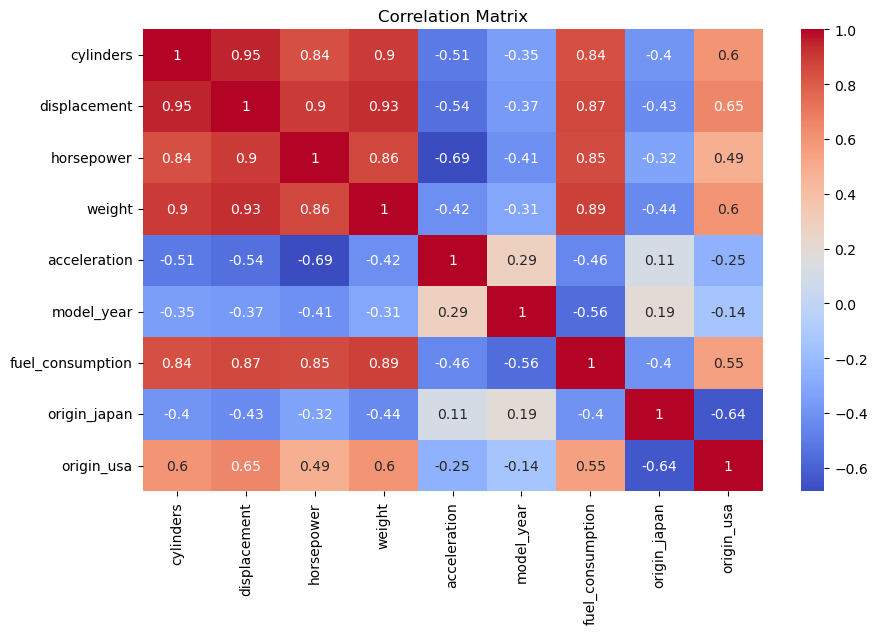

In [36]:
# correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Features and Target

X = df.drop("fuel_consumption", axis=1)
y = df["fuel_consumption"]

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [40]:
# Model 1 : Linear  regression model
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
# Model 2: Decision Tree model

dt= DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [41]:
# Model Evaluation

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)
    print()
    
    return mae, mse, r2

In [42]:
# Evaluation of both model
lr_results = evaluate_model(lr, "Linear Regression")
dt_results = evaluate_model(dt, "Decision Tree")

--- Linear Regression ---
MAE: 1.0053285329200479
MSE: 1.969334951616668
R2 Score: 0.8715981907709309

--- Decision Tree ---
MAE: 1.1510701564164605
MSE: 3.452278534018233
R2 Score: 0.7749093878790285



In [43]:
# Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [lr_results[0], dt_results[0]],
    "MSE": [lr_results[1], dt_results[1]],
    "R2 Score": [lr_results[2], dt_results[2]]
})

results

,Model,MAE,MSE,R2 Score
0,Linear Regression,1.005329,1.969335,0.871598
1,Decision Tree,1.151070,3.452279,0.774909


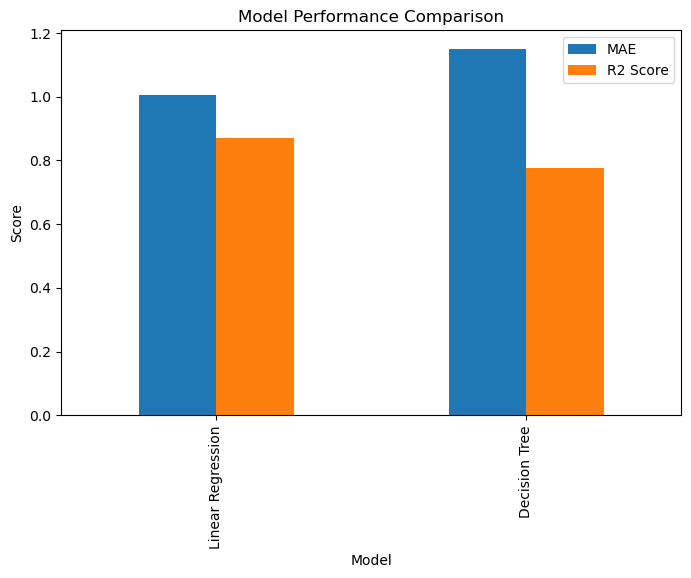

In [44]:
# Model Visual Comparisson
results.set_index("Model")[["MAE", "R2 Score"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

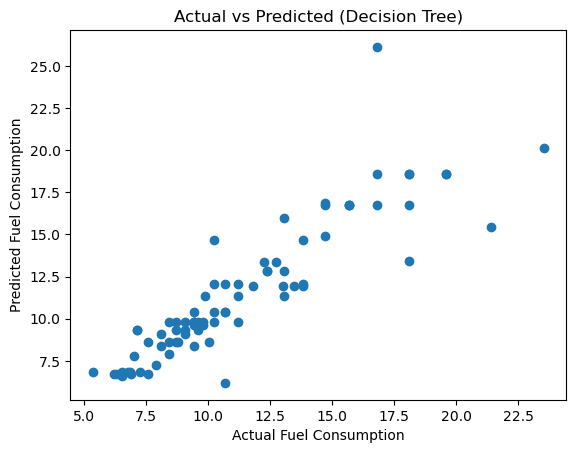

In [45]:
# Actual vs Predicted Plot
y_pred_dt = dt.predict(X_test)

plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Fuel Consumption")
plt.ylabel("Predicted Fuel Consumption")
plt.title("Actual vs Predicted (Decision Tree)")
plt.show()

In [51]:
# Select best model
best_model =lr 

# save the best model
joblib.dump(best_model,"model.pkl")

['model.pkl']

In [49]:
# final verification
loaded_model = joblib.load("model.pkl")
loaded_model.predict(X_test[:5])

array([ 6.77437691,  8.18181597, 11.81025261, 15.14546734, 17.00486603])